# 04 - Steering, neuron baseline, and UMAP

Owner: Areeb

Activation patching, SAE feature steering, neuron monosemanticity
baseline, and a UMAP of the SAE decoder.


## Setup

In [1]:
import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import torch
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from mid.config import load_sae_config

MODEL_CFG_YAML = REPO / "configs" / "model_decoder_small.yaml"
MODEL_CHECKPOINT = REPO / "checkpoints" / "decoder_small_best_model.pt"
SAE_CFG_YAML = REPO / "configs" / "sae_decoder_small.yaml"
TOKENIZER_PATH = REPO / "tokenizer_output" / "tokenizer.json"

sae_cfg = load_sae_config(str(SAE_CFG_YAML))
SAE_DIR = REPO / f"data/sae_out/decoder_small/L{sae_cfg.layer}_{sae_cfg.hook_type}"

TARGET_LAYER = sae_cfg.layer
SAE_HOOK_NAME = sae_cfg.hook_name()
MLP_HOOK_NAME = f"blocks.{TARGET_LAYER}.mlp.hook_post"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("SAE dir:", SAE_DIR.relative_to(REPO))


Device: cpu
SAE dir: data/sae_out/decoder_small/L3_stream


## Load model and SAE

In [3]:
from mid.config import load_configs
from mid.model.hooked_model import load_checkpoint

model_cfg, _ = load_configs(str(MODEL_CFG_YAML))
model = load_checkpoint(str(MODEL_CHECKPOINT), model_cfg)
model.eval()
print(f"model: {sum(p.numel() for p in model.parameters()):,} params, "
      f"d_model={model_cfg.d_model}, n_layers={model_cfg.n_layers}")


Moving model to device:  cpu
Model parameters: 1,597,112
Moving model to device:  cpu
model: 1,597,112 params, d_model=128, n_layers=4


In [4]:
from tokenizers import Tokenizer as HFTokenizer
from transformers import PreTrainedTokenizerFast

hf_tok = HFTokenizer.from_file(str(TOKENIZER_PATH))
pt_tok = PreTrainedTokenizerFast(
    tokenizer_object=hf_tok,
    bos_token="<|bos|>", eos_token="<|eos|>",
    unk_token="<|unk|>", pad_token="<|pad|>",
)
# set_tokenizer() tries to fetch a BOS variant from the HF Hub, which fails
# for our local BPE tokenizer. Wire it on by hand and disable BOS prepending.
model.tokenizer = pt_tok
model.cfg.tokenizer_prepends_bos = False
model.cfg.default_prepend_bos = False
print(model.to_tokens("HAMLET:").shape)


torch.Size([1, 2])


In [5]:
from mid.sae.load import load_sae

# SAE checkpoint expected at data/sae_out/decoder_small/L{layer}_{hook_type}/;
# regenerate via notebooks/02b_train_sae.ipynb if absent.
sae = load_sae(str(SAE_DIR), device=DEVICE)
sae.eval()
print(f"SAE: d_in={sae.cfg.d_in}, d_sae={sae.cfg.d_sae}, hook={sae.cfg.metadata.hook_name}")


SAE: d_in=128, d_sae=1024, hook=blocks.3.hook_resid_post


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


## Activation patching

In [6]:
from mid.analysis.patching import patch_activation, compare_outputs

clean_prompt     = "HAMLET:\nTo be, or not to be, that is the"
corrupted_prompt = "FALSTAFF:\nA plague upon thy house, thou villainous"

clean_len = model.to_tokens(clean_prompt).shape[1]
corr_len  = model.to_tokens(corrupted_prompt).shape[1]
pos = min(clean_len, corr_len) - 1
print(f"clean_len={clean_len}, corr_len={corr_len}, patching at pos={pos}")

for layer in range(model_cfg.n_layers):
    hook = f"blocks.{layer}.hook_resid_post"
    delta = patch_activation(model, clean_prompt, corrupted_prompt, hook, pos)
    print(f"layer {layer}: patched_loss - clean_loss = {delta:+.4f}")


clean_len=14, corr_len=12, patching at pos=11
layer 0: patched_loss - clean_loss = +0.2791
layer 1: patched_loss - clean_loss = +0.1699
layer 2: patched_loss - clean_loss = +0.2455
layer 3: patched_loss - clean_loss = +0.2275


In [7]:
from functools import partial

_, corrupted_cache = model.run_with_cache(model.to_tokens(corrupted_prompt))
layer_to_show = 2
hook_to_show = f"blocks.{layer_to_show}.hook_resid_post"

def patch_hook(act, hook, src):
    act[:, pos, :] = src[:, pos, :]
    return act

top = compare_outputs(
    model, clean_prompt, hook_to_show,
    partial(patch_hook, src=corrupted_cache[hook_to_show]),
    top_k=10,
)
print("CLEAN top-10:", top["clean"])
print("PATCHED top-10:", top["patched"])


CLEAN top-10: [(' King', 0.040103036910295486), (' very', 0.019684934988617897), (' world', 0.018494542688131332), (' Duke', 0.016790812835097313), (' man', 0.01244278158992529), (' p', 0.011449355632066727), (' name', 0.011192037723958492), (' c', 0.010237695649266243), (' court', 0.010002752766013145), (' g', 0.009635119698941708)]
PATCHED top-10: [(' King', 0.03958643972873688), (' very', 0.02070879377424717), (' Duke', 0.017334265634417534), (' world', 0.01689571514725685), (' p', 0.011712833307683468), (' man', 0.011589348316192627), (' name', 0.010388377122581005), (' g', 0.010073336772620678), (' c', 0.010029108263552189), (' matter', 0.009954621084034443)]


## Feature steering

In [8]:
from mid.analysis.patching import steer_with_feature

FEATURE_IDX = 42
PROMPT = "HAMLET:\nTo be"

for coeff in [0.0, 2.0, 5.0, -2.0]:
    out = steer_with_feature(
        model, sae, FEATURE_IDX, coefficient=coeff,
        prompt=PROMPT, max_new_tokens=30,
    )
    print(f"coeff={coeff:+.1f}: {out}\n")


coeff=+0.0: HAMLET:
To be a man, and a man, a man, a man,
That he is a man, a man, a man, a man,




coeff=+2.0: HAMLET:
To be a man, and that he is a king.

KING HENRY
I am a gentleman of a king, and I know
That he is



coeff=+5.0: HAMLET:
To be a man, and that he is a man.

KING,
I am a man that, and that he is a man.





coeff=-2.0: HAMLET:
To be the King's coming, and let me see the
boyage of the King's name.

KING HENRY
I am not sore



## Neuron baseline

In [9]:
from mid.analysis.neuron_baseline import (
    top_activating_neurons, score_monosemanticity, summarize_neuron,
)
import numpy as np

val_ids = np.load(REPO / "tokenizer_output" / "val.npy")
seq_len = 128
n_seqs = 64
slab = val_ids[: n_seqs * seq_len].reshape(n_seqs, seq_len)
dataset_tokens = torch.from_numpy(slab).long().to(DEVICE)
print("dataset_tokens:", dataset_tokens.shape)


dataset_tokens: torch.Size([64, 128])


In [10]:
neuron_top = top_activating_neurons(
    model, dataset_tokens, MLP_HOOK_NAME, k=10, context_window=6,
)
print(f"scored {len(neuron_top)} neurons")

neuron_scores = score_monosemanticity(neuron_top)
example = summarize_neuron(0, neuron_top)
print("neuron 0 top tokens:", example["top_tokens"][:5])
print("neuron 0 sample context:", example["contexts"][0][0][:120])


scored 512 neurons
neuron 0 top tokens: [('the', 2), ('and', 2), ('any', 1), ('power', 1), ('To', 1)]
neuron 0 sample context:  any power
To expel sickness, but pro


### LLM-scored subset

Run the Claude-based scorer on a small sample. Gated on `ANTHROPIC_API_KEY`
so the notebook still runs without credentials.


In [11]:
import os
if os.environ.get("ANTHROPIC_API_KEY"):
    sample_top = {i: neuron_top[i] for i in list(neuron_top)[:10]}
    llm_scores = score_monosemanticity(sample_top, llm_client="anthropic")
    for i, s in sorted(llm_scores.items(), key=lambda kv: -kv[1]):
        print(f"neuron {i}: llm={s:.2f}  heuristic={neuron_scores[i]:.2f}")
else:
    print("ANTHROPIC_API_KEY not set; skipping LLM scoring demo")


ANTHROPIC_API_KEY not set; skipping LLM scoring demo


### SAE feature baseline

In [12]:
with torch.no_grad():
    _, resid_cache = model.run_with_cache(dataset_tokens, names_filter=SAE_HOOK_NAME)
    resid = resid_cache[SAE_HOOK_NAME]
    feat = sae.encode(resid)

def _top_contexts_from_acts(acts, tokens, k=10, ctx=6):
    B, S, F_ = acts.shape
    flat = acts.reshape(-1, F_)
    top_vals, top_pos = flat.topk(k, dim=0)
    out = {}
    for fi in range(F_):
        rows = []
        for r in range(k):
            idx = top_pos[r, fi].item()
            b, s = divmod(idx, S)
            a, z = max(0, s - ctx), min(S, s + ctx + 1)
            snippet = model.to_string(tokens[b, a:z])
            rows.append((snippet, top_vals[r, fi].item()))
        out[fi] = rows
    return out

feat_top = _top_contexts_from_acts(feat, dataset_tokens, k=10, ctx=6)
feature_scores = score_monosemanticity(feat_top)
print(f"scored {len(feature_scores)} SAE features")


scored 1024 SAE features


### Side-by-side

                     n_neurons: 512
                    n_features: 1024
                   neuron_mean: 0.1467145543372174
                  feature_mean: 0.1621116491029404
                 neuron_median: 0.14102564102564108
                feature_median: 0.1578947368421053
     neuron_interpretable_frac: 0.0
    feature_interpretable_frac: 0.0029296875


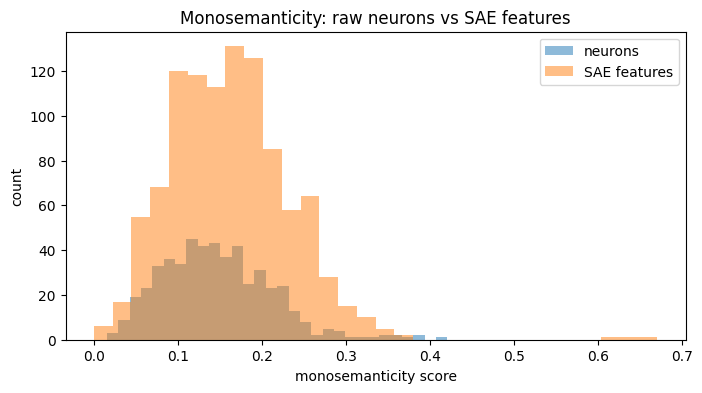

In [13]:
from mid.analysis.neuron_baseline import compare_to_sae

summary = compare_to_sae(neuron_scores, feature_scores, threshold=0.5)
for k, v in summary.items():
    if k.endswith("_sorted"):
        continue
    print(f"{k:>30s}: {v}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(summary["neuron_scores_sorted"], bins=30, alpha=0.5, label="neurons")
ax.hist(summary["feature_scores_sorted"], bins=30, alpha=0.5, label="SAE features")
ax.set_xlabel("monosemanticity score")
ax.set_ylabel("count")
ax.set_title("Monosemanticity: raw neurons vs SAE features")
ax.legend()
plt.show()


## UMAP of SAE decoder directions

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


embeddings: (1024, 2)


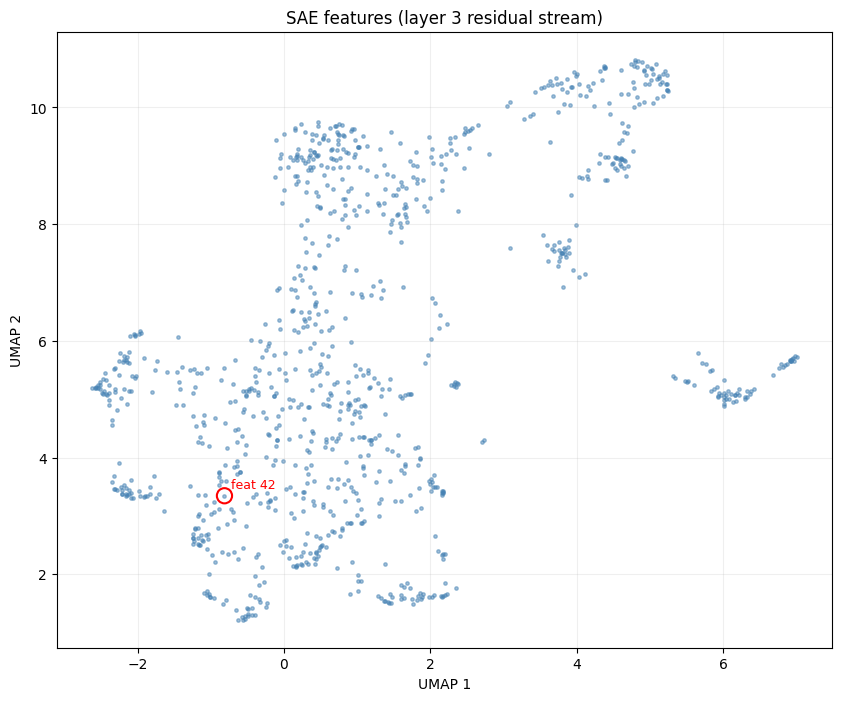

In [14]:
from mid.analysis.umap_features import project_features, plot_feature_map

emb, fidx = project_features(sae, n_components=2, n_neighbors=15,
                             min_dist=0.1, metric="cosine")
print("embeddings:", emb.shape)

fig = plot_feature_map(
    emb,
    highlight_idxs=[FEATURE_IDX],
    title=f"SAE features (layer {TARGET_LAYER} residual stream)",
)
plt.show()


### LLM vs heuristic + save scores

In [15]:
import json
from pathlib import Path

scores_out = {
    "neuron_heuristic": neuron_scores,
    "feature_heuristic": feature_scores,
}

if os.environ.get("ANTHROPIC_API_KEY"):
    feat_sample = {i: feat_top[i] for i in list(feat_top)[:10]}
    feature_llm_scores = score_monosemanticity(feat_sample, llm_client="anthropic")
    scores_out["neuron_llm"] = llm_scores
    scores_out["feature_llm"] = feature_llm_scores

    fig, ax = plt.subplots(figsize=(6, 6))
    n_x = [neuron_scores[i] for i in llm_scores]
    n_y = [llm_scores[i] for i in llm_scores]
    f_x = [feature_scores[i] for i in feature_llm_scores]
    f_y = [feature_llm_scores[i] for i in feature_llm_scores]
    ax.scatter(n_x, n_y, label="neurons", alpha=0.7)
    ax.scatter(f_x, f_y, label="SAE features", alpha=0.7, marker="^")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
    ax.set_xlabel("heuristic score")
    ax.set_ylabel("LLM score")
    ax.set_title("LLM vs heuristic monosemanticity (sampled subset)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(); ax.grid(alpha=0.2)
    plt.show()
else:
    print("ANTHROPIC_API_KEY not set; saving heuristic scores only")

out_path = REPO / "data" / "monosemanticity_scores.json"
out_path.parent.mkdir(exist_ok=True)
out_path.write_text(json.dumps({
    k: {str(i): float(v) for i, v in d.items()} for k, d in scores_out.items()
}, indent=2))
print(f"wrote {out_path.relative_to(REPO)}")


ANTHROPIC_API_KEY not set; saving heuristic scores only
wrote data/monosemanticity_scores.json
